In [2]:
import pandas as pd
import numpy as np
import sklearn

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Scikit-Learn version:", sklearn.__version__)
print("Environment siap digunakan!")

Pandas version: 3.0.6
NumPy version: 2.5.3
Scikit-Learn version: 1.9.1
Environment siap digunakan!


# Project Machine Learning - SDGs 3: Good Health and Well-Being
## Prediksi Risiko Penyakit Jantung menggunakan Algoritma Klasifikasi

* **Topik SDGs:** Target 3.4 - Mengurangi angka kematian akibat penyakit tidak menular melalui pencegahan dan penanganan.
* **Tujuan Project:** Membandingkan 3 algoritma Machine Learning (Logistic Regression, Decision Tree, dan Random Forest) untuk memprediksi risiko penyakit jantung berdasarkan data klinis pasien.
* **Dataset:** Heart Failure Prediction Dataset (Kaggle)

In [3]:
# Import library untuk manipulasi data
import pandas as pd
import numpy as np

# Import library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk preprocessing dan Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Import library untuk menyimpan model
import joblib

# Pengaturan tampilan grafik
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Semua library berhasil di-import!")

Semua library berhasil di-import!


In [4]:
# Membaca dataset dari folder dataset/
# Karakter '../' digunakan jika file notebook berada di dalam folder 'notebooks/'
try:
    df = pd.read_csv('../dataset/heart.csv')
    print("Dataset berhasil dibaca!")
except FileNotFoundError:
    # Alternatif path jika notebook berada di root folder
    df = pd.read_csv('dataset/heart.csv')
    print("Dataset berhasil dibaca dari root folder!")

# Menampilkan 5 baris pertama data
df.head()

Dataset berhasil dibaca!


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
# Menampilkan informasi ringkas mengenai dataset
print(f"Jumlah Baris: {df.shape[0]}")
print(f"Jumlah Kolom: {df.shape[1]}")
print("\n--- Tipe Data dan Informasi Non-Null ---")
df.info()

Jumlah Baris: 918
Jumlah Kolom: 12

--- Tipe Data dan Informasi Non-Null ---
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [6]:
# Menampilkan statistik deskriptif untuk fitur angka
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


C:\Users\muhhi\AppData\Local\Temp\ipykernel_3864\496152701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='HeartDisease', data=df, palette=['#2ecc71', '#e74c3c'])


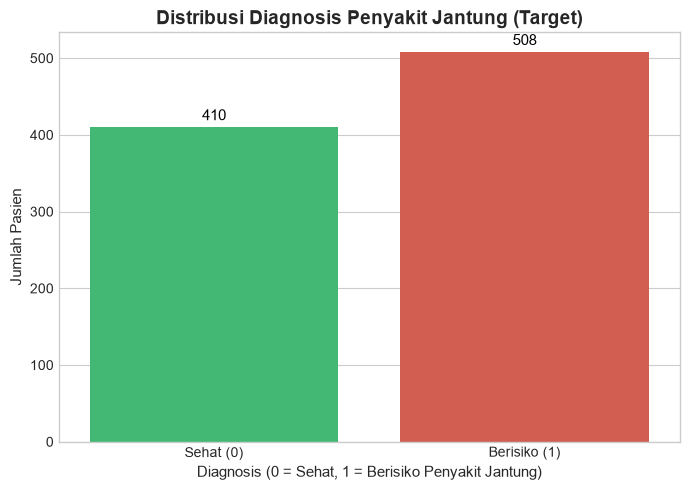

In [7]:
# Membuat figure untuk visualisasi
plt.figure(figsize=(7, 5))

# Membuat diagram batang
ax = sns.countplot(x='HeartDisease', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribusi Diagnosis Penyakit Jantung (Target)', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis (0 = Sehat, 1 = Berisiko Penyakit Jantung)', fontsize=11)
plt.ylabel('Jumlah Pasien', fontsize=11)
plt.xticks([0, 1], ['Sehat (0)', 'Berisiko (1)'])

# Menambahkan angka statistik di atas batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

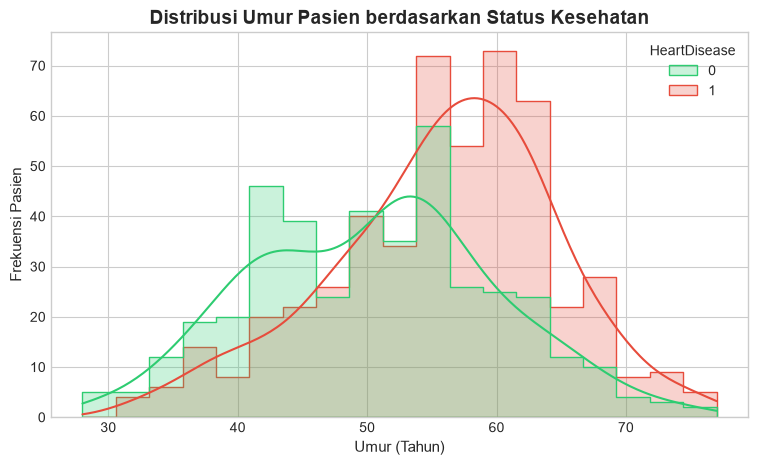

In [8]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='Age', hue='HeartDisease', element='step', kde=True, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribusi Umur Pasien berdasarkan Status Kesehatan', fontsize=14, fontweight='bold')
plt.xlabel('Umur (Tahun)', fontsize=11)
plt.ylabel('Frekuensi Pasien', fontsize=11)
plt.show()

C:\Users\muhhi\AppData\Local\Temp\ipykernel_3864\441918287.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Laki-laki (M)', 'Perempuan (F)'])


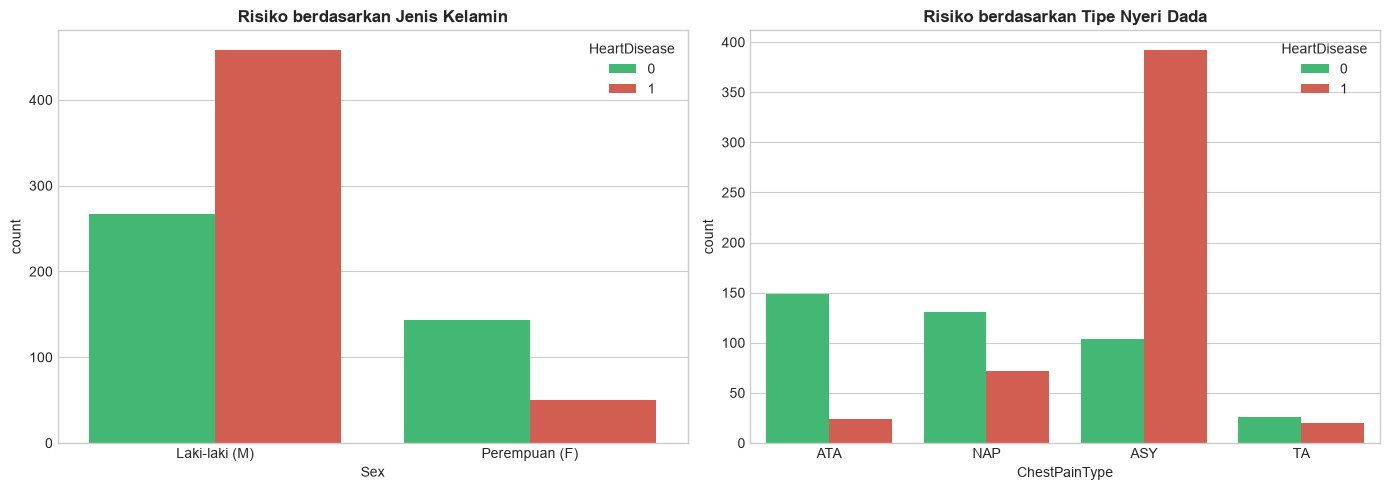

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik 1: Jenis Kelamin vs HeartDisease
sns.countplot(ax=axes[0], x='Sex', hue='HeartDisease', data=df, palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Risiko berdasarkan Jenis Kelamin', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Laki-laki (M)', 'Perempuan (F)'])

# Grafik 2: Tipe Nyeri Dada vs HeartDisease
sns.countplot(ax=axes[1], x='ChestPainType', hue='HeartDisease', data=df, palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Risiko berdasarkan Tipe Nyeri Dada', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# Cek berapa banyak data cholesterol bernilai 0
zero_chol = (df['Cholesterol'] == 0).sum()
print(f"Jumlah baris dengan Cholesterol = 0: {zero_chol}")

# Hitung nilai median dari cholesterol yang nilainya > 0
median_chol = df[df['Cholesterol'] > 0]['Cholesterol'].median()

# Ganti nilai 0 dengan nilai median
df['Cholesterol'] = df['Cholesterol'].replace(0, median_chol)

print(f"Nilai 0 berhasil diganti dengan nilai median: {median_chol}")
print(f"Sisa data Cholesterol = 0: {(df['Cholesterol'] == 0).sum()}")

Jumlah baris dengan Cholesterol = 0: 172
Nilai 0 berhasil diganti dengan nilai median: 237.0
Sisa data Cholesterol = 0: 0


In [11]:
# Menggunakan pd.get_dummies untuk One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

print("Bentuk dataset sebelum encoding:", df.shape)
print("Bentuk dataset setelah encoding:", df_encoded.shape)

# Menampilkan 5 baris pertama data hasil encoding
df_encoded.head()

Bentuk dataset sebelum encoding: (918, 12)
Bentuk dataset setelah encoding: (918, 16)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0.0,0,1,0,1,0,1,0,0,0,1


In [12]:
# Fitur (X) = Semua kolom KECUALI HeartDisease
X = df_encoded.drop(columns=['HeartDisease'])

# Target (y) = Kolom HeartDisease saja
y = df_encoded['HeartDisease']

print("Ukuran Fitur (X):", X.shape)
print("Ukuran Target (y):", y.shape)

Ukuran Fitur (X): (918, 15)
Ukuran Target (y): (918,)


In [13]:
# Membagi data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah Data Latih (X_train): {X_train.shape[0]} baris")
print(f"Jumlah Data Uji (X_test)  : {X_test.shape[0]} baris")

Jumlah Data Latih (X_train): 734 baris
Jumlah Data Uji (X_test)  : 184 baris


In [14]:
# Inisialisasi StandardScaler
scaler = StandardScaler()

# Scaling hanya dilakukan pada X_train (fit) lalu diterpakan ke X_train dan X_test (transform)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling berhasil dilakukan!")

Feature scaling berhasil dilakukan!


In [15]:
# Import algoritma tambahan
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import GaussianNB

# Inisialisasi 6 model Machine Learning
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': CalibratedClassifierCV(SVC(random_state=42), ensemble=False),
    'Naive Bayes': GaussianNB()
}

# Dictionary untuk menyimpan hasil prediksi setiap model
predictions = {}

# Proses training untuk setiap model
print("--- Memulai Proses Training Model ---")
for name, model in models.items():
    # Melatih model dengan data latih
    model.fit(X_train_scaled, y_train)
    
    # Memprediksi data uji
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    print(f"Model [{name}] selesai dilatih!")

--- Memulai Proses Training Model ---
Model [Logistic Regression] selesai dilatih!
Model [Decision Tree] selesai dilatih!
Model [Random Forest] selesai dilatih!
Model [K-Nearest Neighbors] selesai dilatih!
Model [Support Vector Machine] selesai dilatih!
Model [Naive Bayes] selesai dilatih!


In [16]:
results_list = []

for name, y_pred in predictions.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

# Mengubah hasil evaluasi menjadi DataFrame dan mengurutkan berdasarkan Akurasi
df_results = pd.DataFrame(results_list)
df_results = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("--- HASIL PERBANDINGAN 6 MODEL MACHINE LEARNING ---")
df_results

--- HASIL PERBANDINGAN 6 MODEL MACHINE LEARNING ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.896739,0.895238,0.921569,0.908213
1,K-Nearest Neighbors,0.885870,0.893204,0.901961,0.897561
2,Naive Bayes,0.875000,0.907216,0.862745,0.884422
3,Random Forest,0.875000,0.891089,0.882353,0.886700
4,Support Vector Machine,0.853261,0.850467,0.892157,0.870813
5,Decision Tree,0.777174,0.790476,0.813725,0.801932


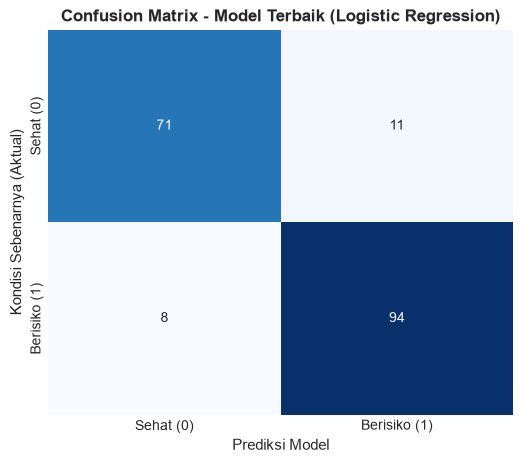


Model Terbaik berdasarkan Akurasi: Logistic Regression


In [17]:
# Ambil nama model dengan akurasi tertinggi
best_model_name = df_results.iloc[0]['Model']
best_pred = predictions[best_model_name]

# Buat Confusion Matrix
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Sehat (0)', 'Berisiko (1)'],
            yticklabels=['Sehat (0)', 'Berisiko (1)'])

plt.title(f'Confusion Matrix - Model Terbaik ({best_model_name})', fontsize=12, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=11)
plt.ylabel('Kondisi Sebenarnya (Aktual)', fontsize=11)
plt.show()

print(f"\nModel Terbaik berdasarkan Akurasi: {best_model_name}")

In [18]:
# Ambil instance model terbaik
best_model = models[best_model_name]

# Contoh Data Pasien Baru (Umur 58, Pria, Kolesterol 280, Nyeri Dada ASY, dll)
# Kita ambil 1 sampel baris dari data uji sebagai simulasi
sample_pasien = X_test.iloc[[0]] 
sample_pasien_scaled = scaler.transform(sample_pasien)

# Melakukan prediksi
prediksi_hasil = best_model.predict(sample_pasien_scaled)[0]
probabilitas = best_model.predict_proba(sample_pasien_scaled)[0]

print("=== HASIL SIMULASI PREDIKSI PASIEN BARU ===")
print(f"Prediksi Label Target : {prediksi_hasil}")

if prediksi_hasil == 1:
    print(f"DIAGNOSA: PASIEN BERISIKO TERKENA PENYAKIT JANTUNG")
    print(f"Tingkat Keyakinan Model: {probabilitas[1] * 100:.2f}%")
else:
    print(f"DIAGNOSA: PASIEN KONDISI NORMAL / SEHAT")
    print(f"Tingkat Keyakinan Model: {probabilitas[0] * 100:.2f}%")

=== HASIL SIMULASI PREDIKSI PASIEN BARU ===
Prediksi Label Target : 1
DIAGNOSA: PASIEN BERISIKO TERKENA PENYAKIT JANTUNG
Tingkat Keyakinan Model: 95.30%


In [19]:
# Menyimpan model terbaik dan scaler ke dalam folder models/
joblib.dump(best_model, '../models/heart_disease_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_columns.pkl')

print("Model, Scaler, dan Daftar Fitur berhasil disimpan ke folder 'models/'!")

Model, Scaler, dan Daftar Fitur berhasil disimpan ke folder 'models/'!
